# Experiment 2- Gan
Dataset- Cifar 10

ref- pytorch gan tutorial and some medium articles


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
latent_dim = 100

In [ ]:
save_path = '/content/drive/MyDrive/GAN_results'
os.makedirs(save_path, exist_ok=True)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize to [-1, 1]
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)


100%|██████████| 170M/170M [00:14<00:00, 11.5MB/s]


In [ ]:
#generator
# Takes random noise and generates fake images
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.net = nn.Sequential(
            # input is noise vector
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False), #kernal, stride, padding
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # output in [-1,1] range
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
#discriminator
# Tells real images from fake ones
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.net = nn.Sequential(
             # Input: 32x32 RGB imag
             # 32x32 → 16x16
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
           
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 4x4 → 1x
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()     # Output probability (0=fake, 1=real)
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [ ]:
# weight initialization helps GAN training stability
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# setup
gen = Generator().to(device)
disc = Discriminator().to(device)
gen.apply(weights_init)
disc.apply(weights_init)

criterion = nn.BCELoss()
opt_gen = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

# fixed noise for visualization each epoch
fixed_noise = torch.randn(16, latent_dim, 1, 1).to(device)

gen_losses = []
disc_losses = []

In [ ]:
#training
num_epochs = 50

for epoch in range(num_epochs):
    gen.train()
    disc.train()

    epoch_gen_loss = 0
    epoch_disc_loss = 0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # train discriminator
        opt_disc.zero_grad()
        out_real = disc(real_imgs)
        loss_real = criterion(out_real, real_labels)

        noise = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake_imgs = gen(noise)
        out_fake = disc(fake_imgs.detach())
        loss_fake = criterion(out_fake, fake_labels)

        disc_loss = loss_real + loss_fake
        disc_loss.backward()
        opt_disc.step()

        # train generator
        opt_gen.zero_grad()
        out_fake2 = disc(fake_imgs)
        gen_loss = criterion(out_fake2, real_labels)  # gen wants disc to say real
        gen_loss.backward()
        opt_gen.step()

        epoch_gen_loss += gen_loss.item()
        epoch_disc_loss += disc_loss.item()

    avg_g = epoch_gen_loss / len(train_loader)
    avg_d = epoch_disc_loss / len(train_loader)
    gen_losses.append(avg_g)
    disc_losses.append(avg_d)

    print(f'Epoch {epoch+1}/{num_epochs}, G_loss: {avg_g:.4f}, D_loss: {avg_d:.4f}')

    # save image grid every 10 epochs
    if (epoch + 1) % 10 == 0:
        gen.eval()
        with torch.no_grad():
            samples = gen(fixed_noise).cpu()
            samples = (samples + 1) / 2  # back to [0,1]

        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for i, ax in enumerate(axes.flat):
            ax.imshow(samples[i].permute(1, 2, 0).numpy())
            ax.axis('off')
        plt.suptitle(f'epoch {epoch+1}')
        plt.savefig(os.path.join(save_path, f'samples_epoch{epoch+1}.png'))
        plt.close()


# save models
torch.save(gen.state_dict(), os.path.join(save_path, 'generator.pth'))
torch.save(disc.state_dict(), os.path.join(save_path, 'discriminator.pth'))


Epoch 1/50, G_loss: 4.6117, D_loss: 0.4444
Epoch 2/50, G_loss: 3.9341, D_loss: 0.4525
Epoch 3/50, G_loss: 3.3695, D_loss: 0.4716
Epoch 4/50, G_loss: 3.4083, D_loss: 0.4638
Epoch 5/50, G_loss: 2.8803, D_loss: 0.5669
Epoch 6/50, G_loss: 2.4404, D_loss: 0.6748
Epoch 7/50, G_loss: 2.4512, D_loss: 0.7231
Epoch 8/50, G_loss: 2.4010, D_loss: 0.7029
Epoch 9/50, G_loss: 2.4953, D_loss: 0.6960
Epoch 10/50, G_loss: 2.4795, D_loss: 0.6496
Epoch 11/50, G_loss: 2.3690, D_loss: 0.7638
Epoch 12/50, G_loss: 2.2322, D_loss: 0.7091
Epoch 13/50, G_loss: 2.2454, D_loss: 0.6855
Epoch 14/50, G_loss: 2.2278, D_loss: 0.7223
Epoch 15/50, G_loss: 2.1809, D_loss: 0.6714
Epoch 16/50, G_loss: 2.1521, D_loss: 0.7856
Epoch 17/50, G_loss: 2.0928, D_loss: 0.7766
Epoch 18/50, G_loss: 2.0473, D_loss: 0.7860
Epoch 19/50, G_loss: 2.0351, D_loss: 0.7816
Epoch 20/50, G_loss: 2.0634, D_loss: 0.7610
Epoch 21/50, G_loss: 2.0352, D_loss: 0.7967
Epoch 22/50, G_loss: 2.0164, D_loss: 0.8170
Epoch 23/50, G_loss: 2.0620, D_loss: 0.77

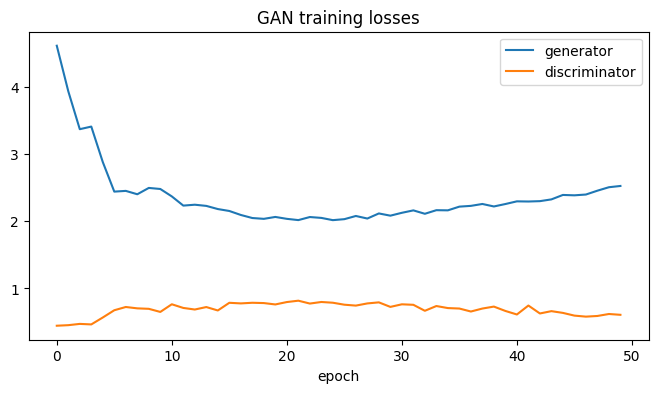

done! saved to drive


In [ ]:
plt.figure(figsize=(8,4))
plt.plot(gen_losses, label='generator')
plt.plot(disc_losses, label='discriminator')
plt.legend()
plt.title('GAN training losses')
plt.xlabel('epoch')
plt.savefig(os.path.join(save_path, 'loss_curves.png'))
plt.show()

print('done! saved to drive')

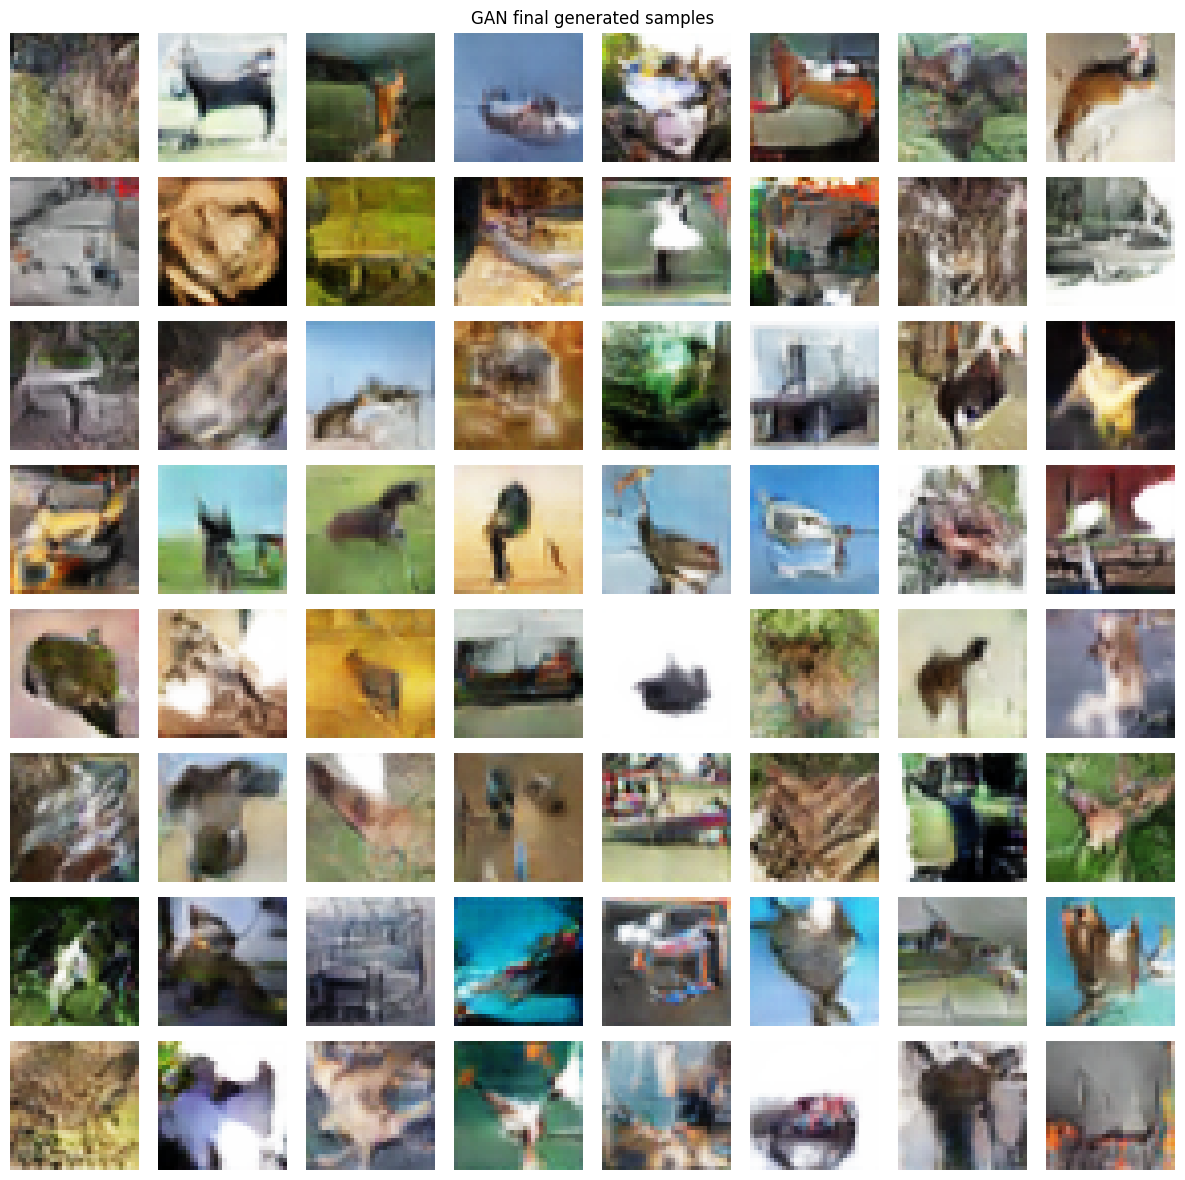

saved to: /content/drive/MyDrive/GAN_results


In [ ]:
gen.eval()
with torch.no_grad():
    noise = torch.randn(64, latent_dim, 1, 1).to(device)
    final_samples = gen(noise).cpu()
    final_samples = (final_samples + 1) / 2  # back to [0,1]

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(final_samples[i].permute(1, 2, 0).numpy())
    ax.axis('off')

plt.suptitle('GAN final generated samples')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'final_generated_samples.png'))
plt.show()

print('saved to:', save_path)